<a href="https://colab.research.google.com/github/itharavenikarthik/Machine-learning/blob/main/2403A52200_ML_Lab_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:

df = pd.read_csv("/content/insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)
print(df_encoded.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:

X = df_encoded[['age','bmi','children','smoker_yes']]
y = df_encoded['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4213.798594527248
MSE: 33981653.95019776
R2 Score: 0.7811147722517886


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

      Feature   Coefficient
0         age    257.071158
1         bmi    327.522631
2    children    427.199971
3  smoker_yes  23653.211646


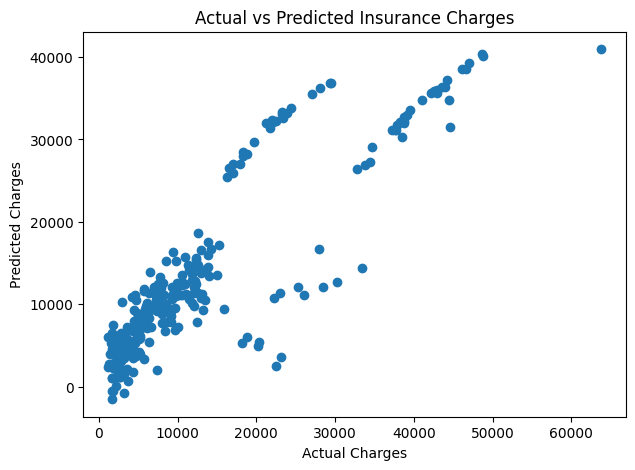

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

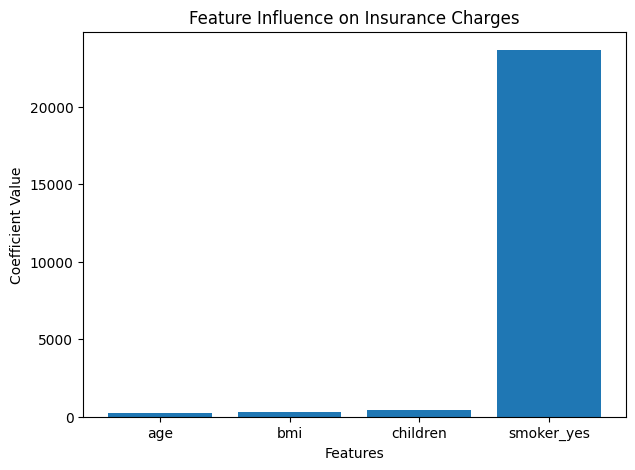

In [ ]:
features = X.columns
coefficients = model.coef_
plt.figure(figsize=(7,5))
plt.bar(features, coefficients)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Influence on Insurance Charges")
plt.show()

<Figure size 700x500 with 0 Axes>

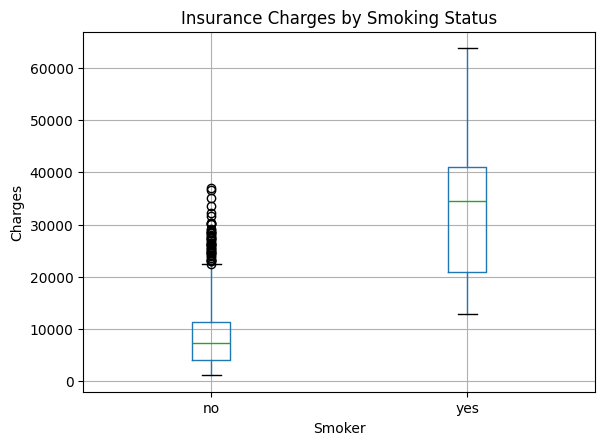

In [ ]:
plt.figure(figsize=(7,5))
df.boxplot(column='charges', by='smoker')
plt.title("Insurance Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()
